# Coletando o theta estimado

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 10 agentes

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é RSME do estado e reward
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é RSME do estado e reward em cada epi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *

import gymnasium as gym
import rlenvs

In [2]:
n_episodes = 100

# env = gym.make("custom/DiscreteCartPole-v1")
env = gym.make("custom/CartPole-v1")

data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
# for i in data:
#     print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [3]:
n_agents = 10

pmbrl = [Model(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [4]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, val=200, verbose=False):
    results = []
    dataset = np.concat(data, axis=0)
    X, y = train_data(build_data(dataset))
    
    for j, agent in enumerate(models):
        if verbose:
            print(f'Agent {j}...')
        agent.train(X[:-val], y[:-val, :-2], **training)
        s,r = agent.sample(X[-val:], mode=training['mode'])
        # p,_ = agent.sample(X[-val:, :-1], mode='param')
        results.append(torch.concat([
                torch.tensor([j]*val).unsqueeze(1),
                (torch.mean((s - y[-val:,:2])**2, axis=0)**.5).repeat(val, 1),
                (torch.mean((r - y[-val:,2])**2, axis=0)**.5).unsqueeze(1)
            ], axis=1))
    
    d = np.array(results).reshape(len(results)*val, results[0].shape[1])
    return pd.DataFrame(d, columns=['agent', 's_0', 's_1', 'r']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [5]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
pmbrl_plot = pmbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

Training pmbrl...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
pmbrl done!


In [6]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
mbrl_plot = mbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

Training mbrl...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
mbrl done!


In [7]:
def add_plot(name, data, axis, reffs, colors=('g', 'b', 'r')):
    # reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(data['s_0'], color = colors[0])
    axis[0].plot(reffs[0], linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5)/10)

    axis[1].plot(data['s_1'], color = colors[1])
    axis[1].plot(reffs[1], linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5)/10)

    axis[2].plot(data['r'], color = colors[2])
    axis[2].plot(reffs[2], linestyle = 'dotted', color = 'r')
    axis[2].set_yticks(np.arange(5)/10)


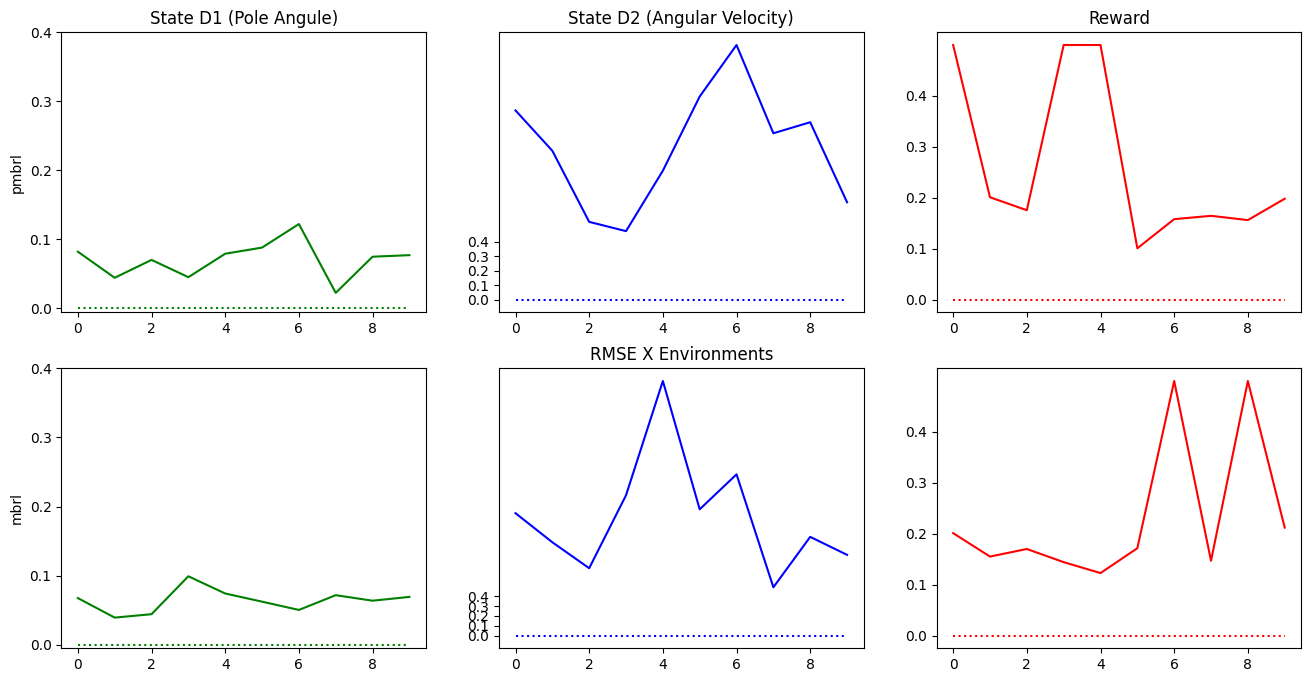

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')

reff = np.zeros(pmbrl_plot.shape[0])

add_plot(f'pmbrl', pmbrl_plot, axs[0], (reff,reff,reff))
add_plot(f'mbrl', mbrl_plot, axs[1], (reff,reff,reff))

plt.show()

# Teste

In [9]:
n_episodes = 10

env = gym.make("custom/CartPole-v1")
data = [generate_episode(env=env) for _ in range(n_episodes)]

for i in data:
    print(i.shape)

(19, 8)
(10, 8)
(47, 8)
(60, 8)
(35, 8)
(15, 8)
(24, 8)
(91, 8)
(6, 8)
(29, 8)


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [10]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode=training['mode'])
                # p,_ = agent.sample(torch.unsqueeze(feature, axis=0)[:, :-1], mode='param')
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:2])**2, axis=0)**.5,
                        torch.mean((r - target[2])**2, axis=0)**.5,
                        # p[0],
                        # y[-1, 3:]
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r']) 


In [11]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 4...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 5...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 6...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 7...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9..

In [12]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 4...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 5...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 6...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 7...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...

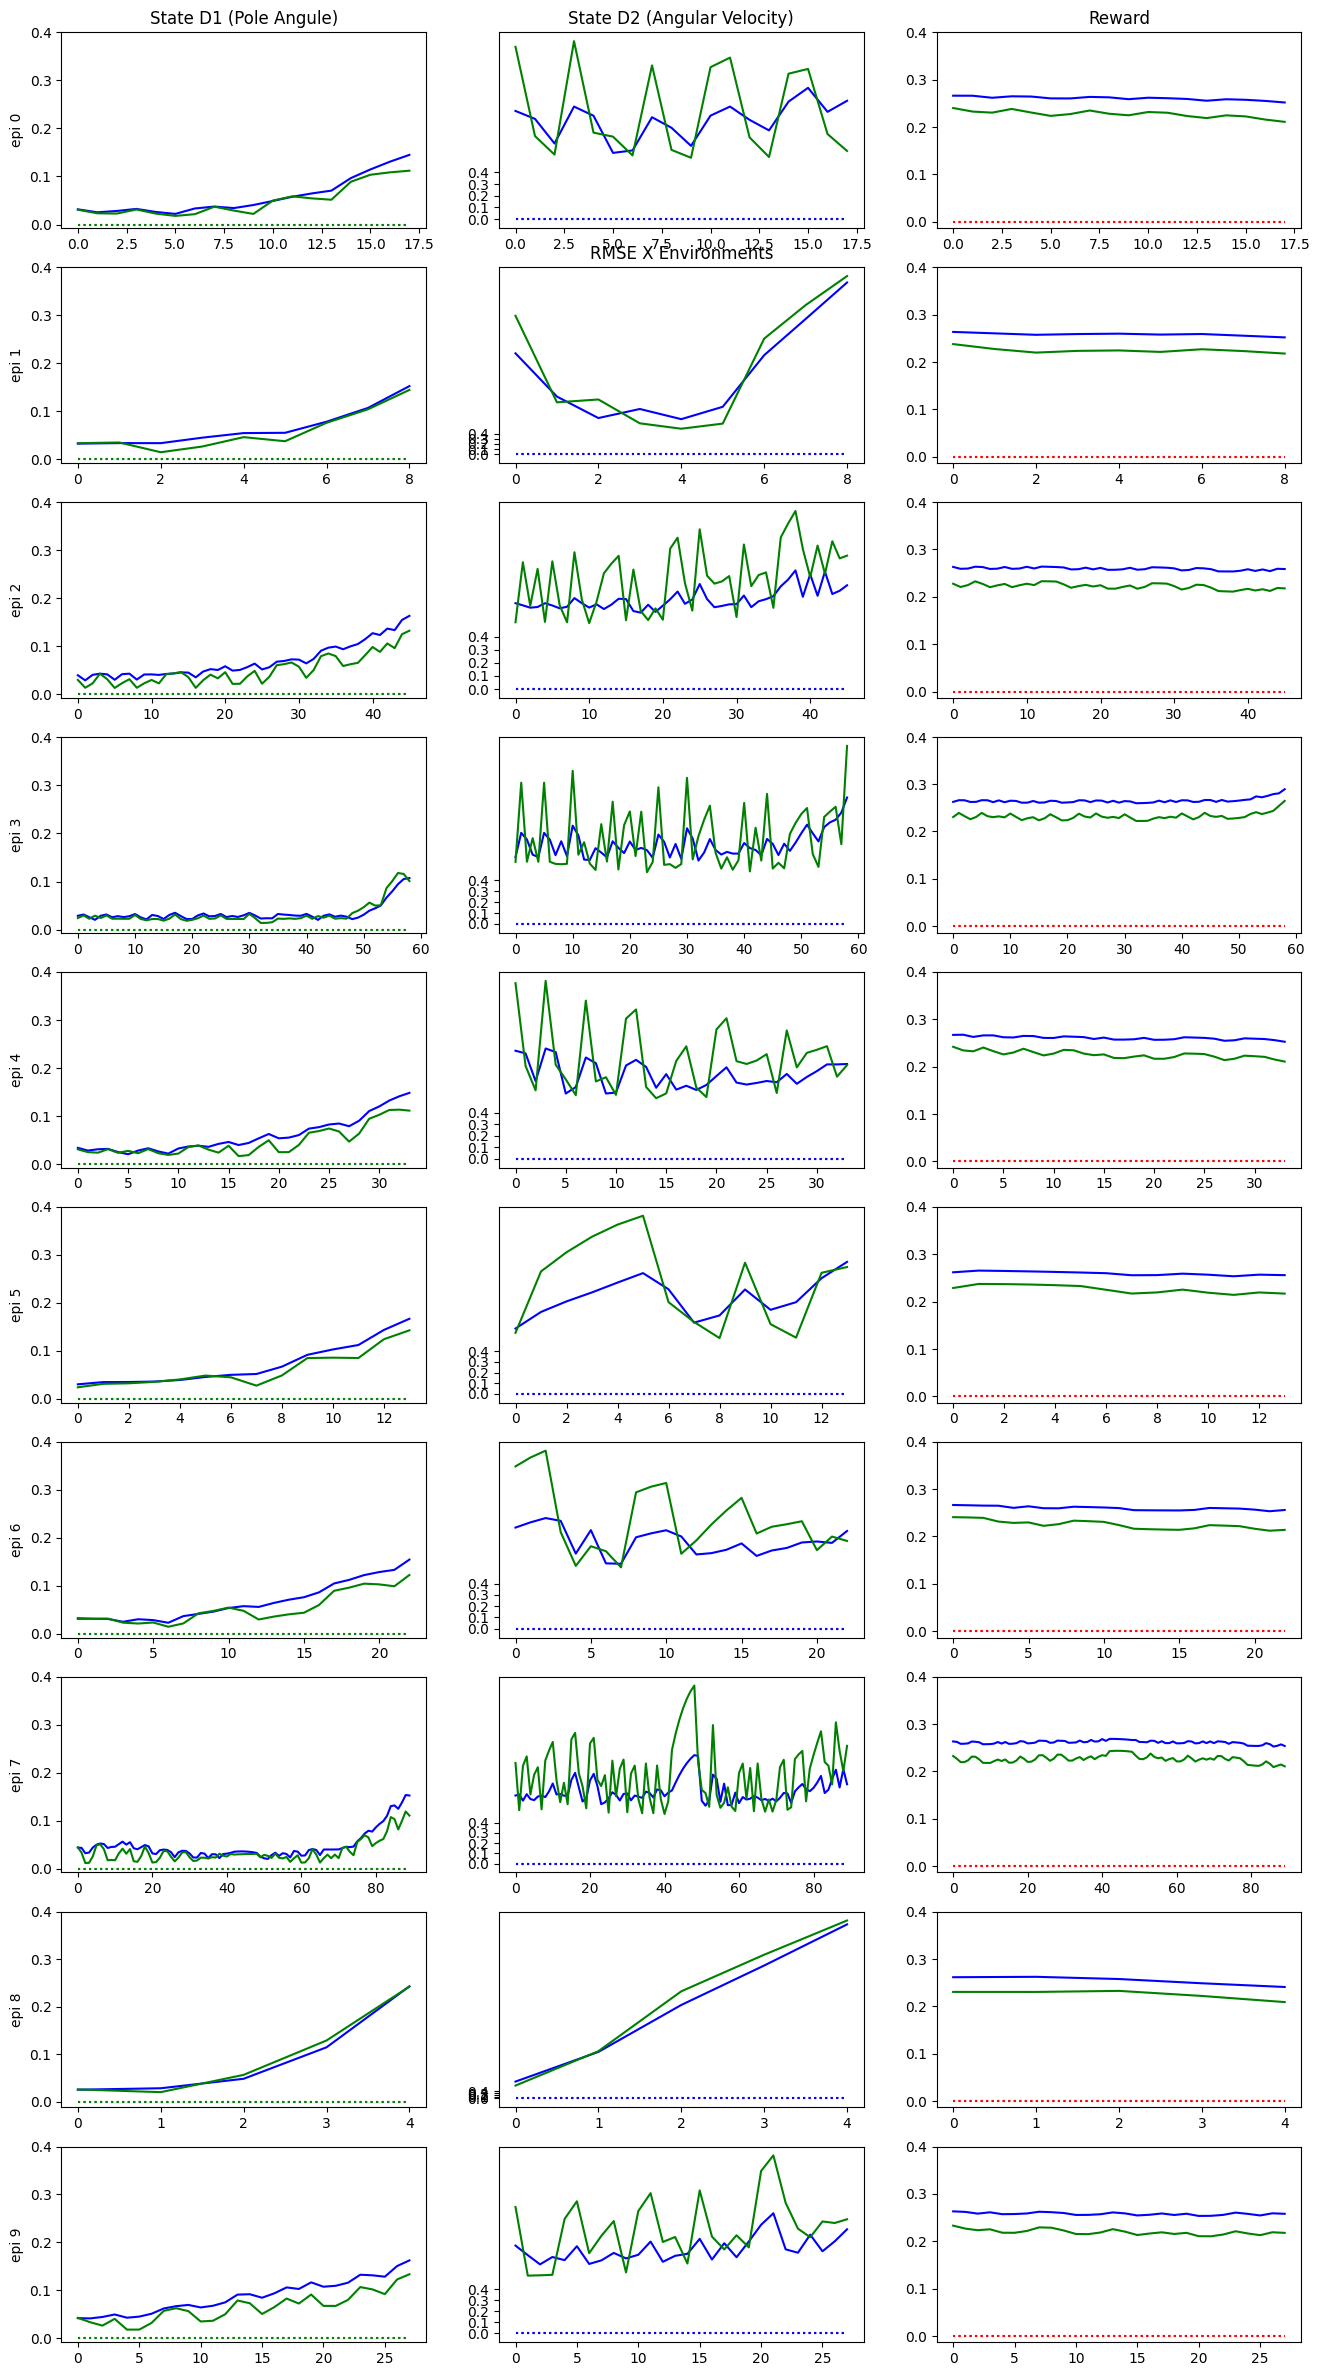

In [13]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(n, 3, figsize=(16, n*3))

# axs[0][0].set_title('Param D1 (masspole)')
# axs[0][1].set_title('Param D2 (length)')

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')


for i in range(n):
    df = pmbrl_plot[pmbrl_plot.epi==i].reset_index()
    reff = np.zeros(df.shape[0])
    add_plot(
        f'epi {i}', 
        df, 
        axs[i],
        (reff, reff, reff),
        ('b', 'b', 'b')
    )
    
    df = mbrl_plot[mbrl_plot.epi==i].reset_index()
    reff = np.zeros(df.shape[0])
    add_plot(
        f'epi {i}', 
        df, 
        axs[i],
        (reff, reff, reff),
        ('g', 'g', 'g')
    )

plt.show()